Step 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !pip install torch torchvision matplotlib scikit-learn numpy tqdm pillow

# Import Libraries

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

All libraries loaded!
PyTorch version: 2.10.0+cu128
GPU available: True


# Load Datasets

In [ ]:
# Define transformations (important: ResNet needs 224x224)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet expects 224x224
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load full CIFAR-10 dataset
full_trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

full_testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Class 5 = "dog" in CIFAR-10 (0=airplane, 1=car, 2=bird, 3=cat, 4=deer,
#                           5=dog, 6=frog, 7=horse, 8=ship, 9=truck)

# Find indices where label is 5 (dog)
train_dog_indices = [i for i, (_, label) in enumerate(full_trainset) if label == 5]
test_dog_indices = [i for i, (_, label) in enumerate(full_testset) if label == 5]

print(f"Found {len(train_dog_indices)} dog images in training set")
print(f"Found {len(test_dog_indices)} dog images in test set")
print(f"Total dog images: {len(train_dog_indices) + len(test_dog_indices)}")

# Create datasets with ONLY dogs
train_dogs = Subset(full_trainset, train_dog_indices)
test_dogs = Subset(full_testset, test_dog_indices)

# Split training dogs into train/validation (90/10)
train_dog_size = int(0.9 * len(train_dogs))
val_dog_size = len(train_dogs) - train_dog_size

train_dog_data, val_dog_data = torch.utils.data.random_split(
    train_dogs, [train_dog_size, val_dog_size]
)

print(f"\n Split sizes:")
print(f"  Training dogs: {len(train_dog_data)}")
print(f"  Validation dogs: {len(val_dog_data)}")
print(f"  Test dogs: {len(test_dogs)}")

# Create data loaders
batch_size = 32  # Smaller batch size for GPU memory
train_dog_loader = DataLoader(train_dog_data, batch_size=batch_size, shuffle=False, num_workers=2)
val_dog_loader = DataLoader(val_dog_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_dog_loader = DataLoader(test_dogs, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"\n Data loaders created!")
print(f"  Train loader: {len(train_dog_loader)} batches")
print(f"  Val loader: {len(val_dog_loader)} batches")
print(f"  Test loader: {len(test_dog_loader)} batches")

Found 5000 dog images in training set
Found 1000 dog images in test set
Total dog images: 6000

 Split sizes:
  Training dogs: 4500
  Validation dogs: 500
  Test dogs: 1000

 Data loaders created!
  Train loader: 141 batches
  Val loader: 16 batches
  Test loader: 32 batches


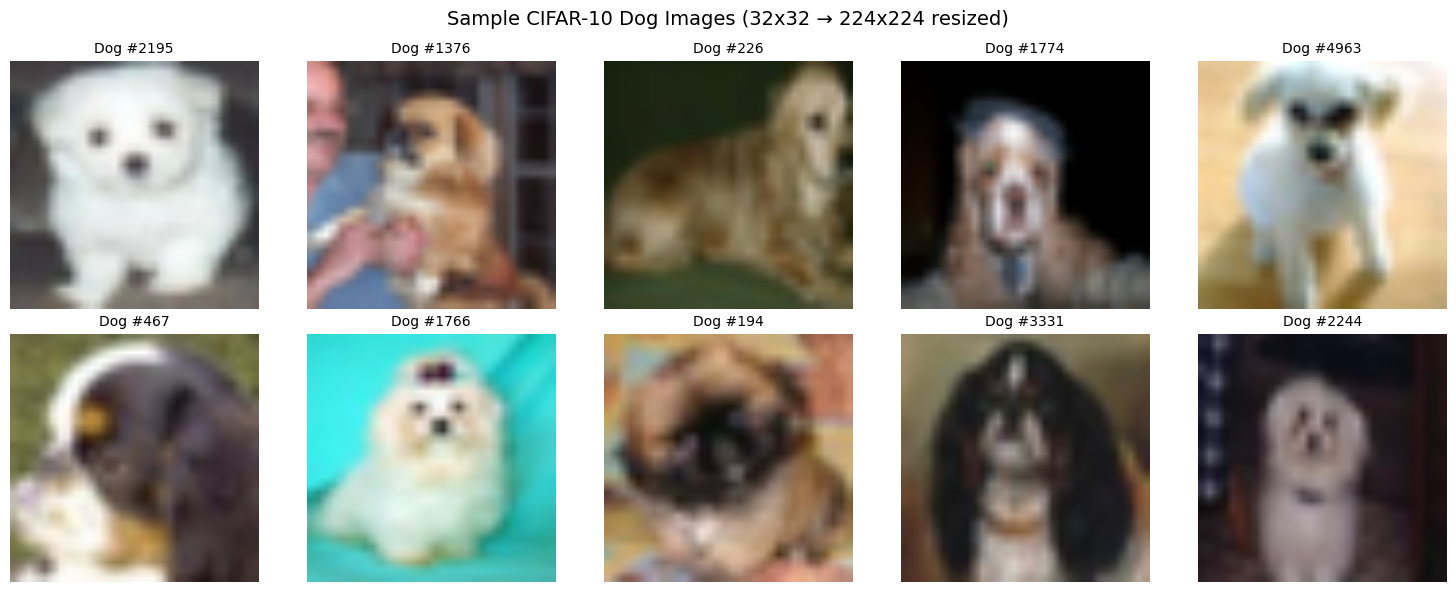

In [ ]:
def show_dog_samples(dataset, num_samples=10):
    """Display sample dog images from the dataset"""
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    for i in range(num_samples):
        # Get random dog
        idx = np.random.randint(0, len(dataset))
        image, label = dataset[idx]

        # Denormalize for display
        image = image.permute(1, 2, 0).numpy()
        image = (image * 0.5) + 0.5  # Reverse normalization
        image = np.clip(image, 0, 1)  # Keep values in valid range

        axes[i].imshow(image)
        axes[i].set_title(f'Dog #{idx}', fontsize=10)
        axes[i].axis('off')

    plt.suptitle('Sample CIFAR-10 Dog Images (32x32 → 224x224 resized)', fontsize=14)
    plt.tight_layout()
    plt.show()

# Show samples
show_dog_samples(train_dogs)

# Load Pretrained ResNet-18

In [ ]:
# ============================================
# STEP 5: Load Pretrained ResNet-18
# ============================================

# Set device (should show CUDA/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pretrained ResNet-18
print("Loading ResNet-18 pretrained on ImageNet...")
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Remove the last classification layer
# Original ResNet-18: [Conv layers] -> [AdaptiveAvgPool] -> [FC (1000 classes)]
# We want: [Conv layers] -> [AdaptiveAvgPool] -> Output features (512 numbers)
resnet18 = torch.nn.Sequential(*list(resnet18.children())[:-1])

# Set to evaluation mode (no dropout, no batch norm updates)
resnet18.eval()

# Move to GPU
resnet18 = resnet18.to(device)

print(f"\n ResNet-18 loaded and ready!")
print(f"   Model architecture:")
print(f"   - {len(list(resnet18.children()))} layers")
print(f"   - Output: 512 features per image")
print(f"   - Parameters: {sum(p.numel() for p in resnet18.parameters()):,}")

# Test with a dummy input
dummy_input = torch.randn(1, 3, 224, 224).to(device)
dummy_output = resnet18(dummy_input)
print(f"   - Test output shape: {dummy_output.shape}")
print(f"   (Expected: torch.Size([1, 512, 1, 1]) or [1, 512])")

Using device: cuda
Loading ResNet-18 pretrained on ImageNet...

 ResNet-18 loaded and ready!
   Model architecture:
   - 9 layers
   - Output: 512 features per image
   - Parameters: 11,176,512
   - Test output shape: torch.Size([1, 512, 1, 1])
   (Expected: torch.Size([1, 512, 1, 1]) or [1, 512])


# Extract Features from Dog Images using ResNet

In [ ]:
# ============================================
# STEP 6 (FIXED): Extract Features from DOGS ONLY
# ============================================

def extract_features(model, dataloader, device, description="Extracting features"):
    """
    Extract feature vectors from all images in a dataloader.
    """
    model.eval()
    features_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=description):
            images = images.to(device)
            batch_features = model(images)
            batch_features = batch_features.view(batch_features.size(0), -1)
            features_list.append(batch_features.cpu().numpy())
            labels_list.append(labels.numpy())

    features = np.concatenate(features_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)

    return features, labels

print("="*50)
print("Starting Feature Extraction (DOGS ONLY)")
print("="*50)

# IMPORTANT: Use the CORRECT loader names from Step 4
# train_dog_loader, val_dog_loader, test_dog_loader (NOT train_loader!)

# Extract from training dogs
train_features, train_labels = extract_features(
    resnet18_feature_extractor,
    train_dog_loader,  # ← FIXED: Use train_dog_loader
    device,
    "Extracting training dog features"
)

# Extract from validation dogs
val_features, val_labels = extract_features(
    resnet18_feature_extractor,
    val_dog_loader,    # ← FIXED: Use val_dog_loader
    device,
    "Extracting validation dog features"
)

# Extract from test dogs
test_features, test_labels = extract_features(
    resnet18_feature_extractor,
    test_dog_loader,   # ← FIXED: Use test_dog_loader
    device,
    "Extracting test dog features"
)

# Print results
print("\n" + "="*50)
print("Feature Extraction Complete!")
print("="*50)
print(f" Training features: {train_features.shape}")
print(f"   → {train_features.shape[0]} dogs, each with {train_features.shape[1]} features")
print(f" Validation features: {val_features.shape}")
print(f" Test features: {test_features.shape}")

# Verify no NaN or Inf values
print("\n Checking feature quality:")
print(f"   Any NaN values? {np.isnan(train_features).any()}")
print(f"   Any Inf values? {np.isinf(train_features).any()}")
print(f"   Feature range: [{train_features.min():.3f}, {train_features.max():.3f}]")

# Verify all labels are dogs (class 5)
print(f"\n Label verification:")
print(f"   Unique labels in training set: {np.unique(train_labels)}")
print(f"   (Should be [5] only!)")

Starting Feature Extraction (DOGS ONLY)


NameError: name 'resnet18_feature_extractor' is not defined

## Check if Feature Range is Reasonable

In [ ]:
# Let's check if your features have good variety
print("\n Feature Statistics:")
print(f"   Mean feature value: {train_features.mean():.4f}")
print(f"   Std feature value: {train_features.std():.4f}")
print(f"   % of features that are zero: {(train_features == 0).sum() / train_features.size * 100:.2f}%")

# Check if features are diverse (good for clustering)
feature_variance = train_features.var(axis=0)
print(f"\n Feature diversity:")
print(f"   Average variance across 512 features: {feature_variance.mean():.4f}")
print(f"   Features with zero variance (useless): {(feature_variance == 0).sum()}")

# Load VGG16

In [ ]:

# ============================================
# STEP 5: Load Pretrained VGG16
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Loading VGG16 pretrained on ImageNet...")
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Remove classifier (keep feature extractor)
# VGG structure: features → avgpool → classifier
vgg16_feature_extractor = torch.nn.Sequential(
    vgg16.features,
    vgg16.avgpool
)

# Set eval mode
vgg16_feature_extractor.eval()

# Move to GPU
vgg16_feature_extractor = vgg16_feature_extractor.to(device)

print(f"\n VGG16 loaded and ready!")
print(f"   Model architecture:")
print(f"   - {len(list(vgg16_feature_extractor.children()))} blocks")
print(f"   - Output: 512 x 7 x 7 = 25088 features per image")
print(f"   - Parameters: {sum(p.numel() for p in vgg16_feature_extractor.parameters()):,}")

# Test with dummy input
dummy_input = torch.randn(1, 3, 224, 224).to(device)
dummy_output = vgg16_feature_extractor(dummy_input)

print(f"   - Test output shape: {dummy_output.shape}")
print(f"   (Expected: torch.Size([1, 512, 7, 7]))")

Using device: cuda
Loading VGG16 pretrained on ImageNet...

 VGG16 loaded and ready!
   Model architecture:
   - 2 blocks
   - Output: 512 x 7 x 7 = 25088 features per image
   - Parameters: 14,714,688
   - Test output shape: torch.Size([1, 512, 7, 7])
   (Expected: torch.Size([1, 512, 7, 7]))


In [ ]:
# Step 6: Feature Extraction for VGG16!
print("="*50)
print("Starting VGG16 Feature Extraction (DOGS ONLY)")
print("="*50)

train_features_vgg, train_labels_vgg = extract_features(
    vgg16_feature_extractor,
    train_dog_loader,
    device,
    "Extracting VGG training dog features"
)

val_features_vgg, val_labels_vgg = extract_features(
    vgg16_feature_extractor,
    val_dog_loader,
    device,
    "Extracting VGG validation dog features"
)

test_features_vgg, test_labels_vgg = extract_features(
    vgg16_feature_extractor,
    test_dog_loader,
    device,
    "Extracting VGG test dog features"
)

Starting VGG16 Feature Extraction (DOGS ONLY)


Extracting VGG test dog features: 100%|██████████| 32/32 [00:05<00:00,  5.71it/s]


In [ ]:
# verify VGG16 features
print("\n" + "="*50)
print("VGG Feature Extraction Complete!")
print("="*50)

print(f" Training features: {train_features_vgg.shape}")
print(f"   → {train_features_vgg.shape[0]} dogs, each with {train_features_vgg.shape[1]} features")

print(f" Validation features: {val_features_vgg.shape}")
print(f" Test features: {test_features_vgg.shape}")

# Sanity checks
print("\n Checking feature quality:")
print(f"   Any NaN values? {np.isnan(train_features_vgg).any()}")
print(f"   Any Inf values? {np.isinf(train_features_vgg).any()}")
print(f"   Feature range: [{train_features_vgg.min():.3f}, {train_features_vgg.max():.3f}]")

print("\n Feature Statistics:")
print(f"   Mean: {train_features_vgg.mean():.4f}")
print(f"   Std: {train_features_vgg.std():.4f}")

# Variance check (VERY IMPORTANT for clustering)
feature_variance_vgg = train_features_vgg.var(axis=0)
print(f"\n Feature diversity:")
print(f"   Avg variance: {feature_variance_vgg.mean():.4f}")
print(f"   Zero-variance features: {(feature_variance_vgg == 0).sum()}")


VGG Feature Extraction Complete!
 Training features: (4500, 25088)
   → 4500 dogs, each with 25088 features
 Validation features: (500, 25088)
 Test features: (1000, 25088)

 Checking feature quality:
   Any NaN values? False
   Any Inf values? False
   Feature range: [0.000, 18.316]

 Feature Statistics:
   Mean: 0.1491
   Std: 0.4862

 Feature diversity:
   Avg variance: 0.1852
   Zero-variance features: 0


In [ ]:
# Before step 7, we need to reduce from 25088 --> 30 (Apply PCA)
# before pca = 30, i tried pca = 100 but my k means clustering was not good.
# I changed it and the result got better, still not good
# discuss this later
from sklearn.decomposition import PCA

print("\nReducing VGG features with PCA...")

pca = PCA(n_components=30)

train_features_vgg_reduced = pca.fit_transform(train_features_vgg)
val_features_vgg_reduced = pca.transform(val_features_vgg)
test_features_vgg_reduced = pca.transform(test_features_vgg)

print(f"Reduced shape: {train_features_vgg_reduced.shape}")


Reducing VGG features with PCA...
Reduced shape: (4500, 30)


In [ ]:
# Step 7: K-means clustering
#normalizing features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
train_scaled = scaler.fit_transform(train_features_vgg_reduced)

# Apply same transformation to val/test
val_scaled = scaler.transform(val_features_vgg_reduced)
test_scaled = scaler.transform(test_features_vgg_reduced)

print("Feature scaling complete!")
print("Train shape:", train_scaled.shape)

Feature scaling complete!
Train shape: (4500, 30)


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10] # Start K from 2
silhouette_scores = []

print("\nTesting K values...\n")

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    cluster_labels = kmeans.fit_predict(train_scaled)

    score = silhouette_score(train_scaled, cluster_labels)
    silhouette_scores.append(score)

    print(f"K = {k} \u2192 Silhouette Score = {score:.4f}")

# selecting the best score:
best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nBest K value: {best_k}")

# final clustering
# clusters represent group of visually similar dogs (not labeled breeds)
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
#fit on training data
train_clusters = kmeans.fit_predict(train_scaled)

#predict for val/test
val_clusters = kmeans.predict(val_scaled)
test_clusters = kmeans.predict(test_scaled)

print("\nFinal clustering complete!")


Testing K values...

K = 2 → Silhouette Score = 0.0542
K = 3 → Silhouette Score = 0.0503
K = 4 → Silhouette Score = 0.0253
K = 5 → Silhouette Score = 0.0173
K = 6 → Silhouette Score = 0.0126
K = 7 → Silhouette Score = 0.0140
K = 8 → Silhouette Score = 0.0103
K = 9 → Silhouette Score = 0.0169
K = 10 → Silhouette Score = 0.0143

Best K value: 2

Final clustering complete!


In [ ]:
#Step 8: Evaluate Clustering quality

#validation silhouette score -
#How well each data point fits into its assigned cluster compared to other clusters
from sklearn.metrics import silhouette_score

val_silhouette = silhouette_score(val_scaled, val_clusters)
print(f"Validation Silhouette Score: {val_silhouette:.4f}")
# we want 0.2-0.4 range for best clusters

inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(train_scaled)
    inertias.append(kmeans.inertia_)

Validation Silhouette Score: 0.0633


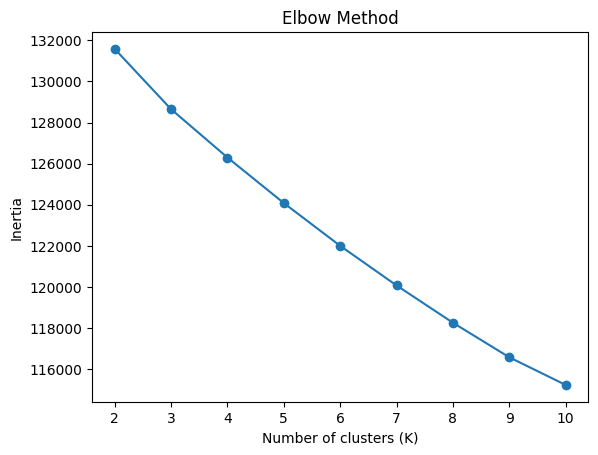

In [ ]:
#elbow method
import matplotlib.pyplot as plt

plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
#STEP 9 VGG16: VISUALIZE DISCOVERED BREEDS

import matplotlib.pyplot as plt
import random

def show_clusters(dataset, clusters, num_clusters, images_per_cluster=6):
    plt.figure(figsize=(images_per_cluster * 2, num_clusters * 2))

    for cluster_id in range(num_clusters):
        # get indices belonging to this cluster
        indices = [i for i, c in enumerate(clusters) if c == cluster_id]

        if len(indices) == 0:
            continue

        # randomly sample images
        selected = random.sample(indices, min(images_per_cluster, len(indices)))

        for j, idx in enumerate(selected):
            img, _ = dataset[idx]

            # unnormalize image
            img = img.permute(1, 2, 0) * 0.5 + 0.5

            plt.subplot(num_clusters, images_per_cluster,
                        cluster_id * images_per_cluster + j + 1)

            plt.imshow(img)
            plt.axis('off')

            if j == 0:
                plt.ylabel(f"Cluster {cluster_id}", fontsize=12)

    plt.suptitle("Discovered Dog Clusters (Pseudo-Breeds)", fontsize=16)
    plt.tight_layout()
    plt.show()

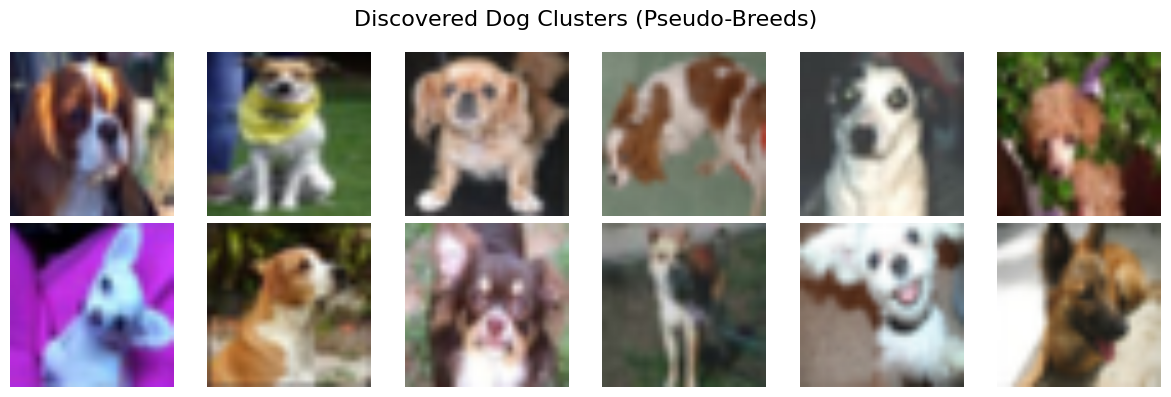

In [ ]:
show_clusters(train_dogs, train_clusters, best_k)

In [ ]:
#save the picture above
plt.savefig("discovered_breeds.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
print("\n" + "="*50)
print("DISCOVERED CLUSTER ANALYSIS")
print("="*50)

for cluster_id in range(best_k):
    cluster_mask = train_clusters == cluster_id
    cluster_size = cluster_mask.sum()

    cluster_features = train_scaled[cluster_mask]

    # statistics
    mean_val = cluster_features.mean()
    std_val = cluster_features.std()

    # spread of cluster (how tight it is)
    distances = np.linalg.norm(cluster_features - cluster_features.mean(axis=0), axis=1)
    avg_distance = distances.mean()

    print(f"\n🐶 Cluster {cluster_id}")
    print(f"   Size: {cluster_size} dogs ({cluster_size/len(train_clusters)*100:.1f}%)")
    print(f"   Feature mean: {mean_val:.4f}")
    print(f"   Feature std: {std_val:.4f}")
    print(f"   Avg distance to center: {avg_distance:.4f}")


cluster_sizes = [np.sum(train_clusters == i) for i in range(best_k)]

print("\nCluster Balance:")
print(cluster_sizes)


DISCOVERED CLUSTER ANALYSIS

🐶 Cluster 0
   Size: 920 dogs (20.4%)
   Feature mean: -0.0187
   Feature std: 1.0745
   Avg distance to center: 5.4281

🐶 Cluster 1
   Size: 3580 dogs (79.6%)
   Feature mean: 0.0048
   Feature std: 0.9799
   Avg distance to center: 5.1793

Cluster Balance:
[np.int64(920), np.int64(3580)]


In [ ]:
#Trying Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

k_values = [2, 3, 4, 5, 6]
agg_silhouette_scores = []

print("\nTesting Agglomerative Clustering...\n")

for k in k_values:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')

    cluster_labels = agg.fit_predict(train_scaled)

    score = silhouette_score(train_scaled, cluster_labels)
    agg_silhouette_scores.append(score)

    print(f"K = {k} → Silhouette Score = {score:.4f}")


Testing Agglomerative Clustering...

K = 2 → Silhouette Score = 0.1510
K = 3 → Silhouette Score = 0.1353
K = 4 → Silhouette Score = 0.0531
K = 5 → Silhouette Score = 0.0361
K = 6 → Silhouette Score = -0.0026


In [ ]:
#Select best K
import numpy as np

best_k_agg = k_values[np.argmax(agg_silhouette_scores)]
print(f"\nBest K (Agglomerative): {best_k_agg}")
agg = AgglomerativeClustering(n_clusters=best_k_agg, linkage='ward')

train_clusters_agg = agg.fit_predict(train_scaled)
val_clusters_agg = agg.fit_predict(val_scaled)  # NOTE: no predict() method

val_silhouette_agg = silhouette_score(val_scaled, val_clusters_agg)

print(f"\nAgglomerative Validation Silhouette: {val_silhouette_agg:.4f}")


Best K (Agglomerative): 2

Agglomerative Validation Silhouette: 0.4155


Hierarchical Clustering (Dendrogram Analysis)

Computing linkage matrix (this may take ~1 min)...


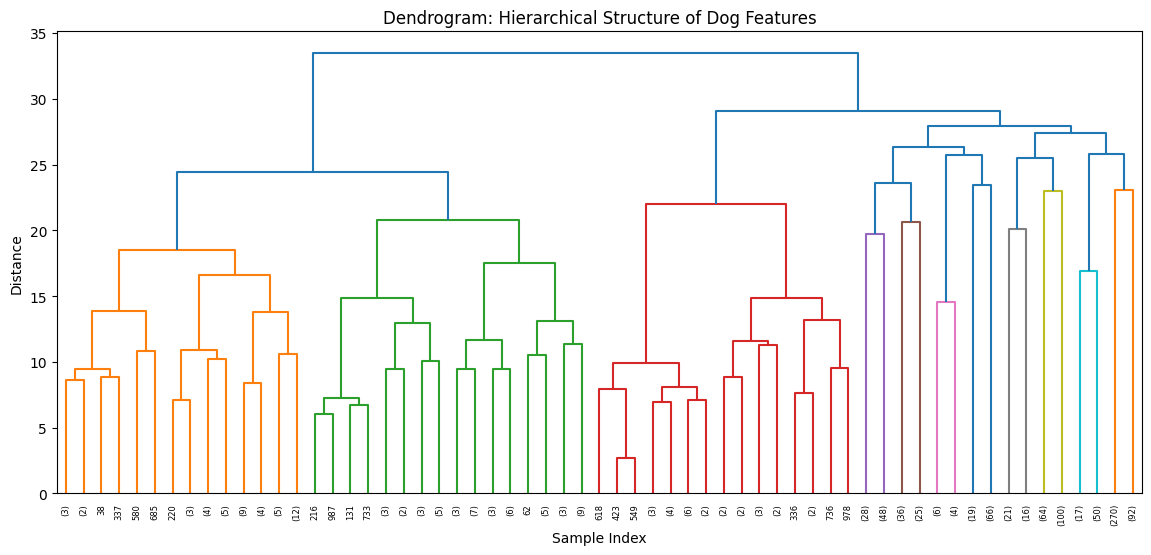


Cutting dendrogram at different heights:
Cut distance=5: 632 clusters, Silhouette=0.0557
Cut distance=7: 303 clusters, Silhouette=0.0573
Cut distance=9: 161 clusters, Silhouette=0.0399
Cut distance=11: 92 clusters, Silhouette=0.0198
Cut distance=13: 59 clusters, Silhouette=0.0125
Cut distance=15: 39 clusters, Silhouette=-0.0066

Best cut distance: 7
Number of clusters: 303
Best silhouette: 0.0573


In [ ]:
#dendrogram

import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score

print("="*50)
print("Hierarchical Clustering (Dendrogram Analysis)")
print("="*50)

# Use subset for speed (IMPORTANT)
subset_size = 1000   # ⚠️ reduce from 2000 → faster + safer
subset_indices = np.random.choice(len(train_scaled), subset_size, replace=False)
subset_features = train_scaled[subset_indices]

#compute linkage matrix
print("\nComputing linkage matrix (this may take ~1 min)...")

linkage_matrix = linkage(subset_features, method='ward')

#plotting dendrogram
plt.figure(figsize=(14, 6))

dendrogram(
    linkage_matrix,
    truncate_mode='level',   # simplifies tree
    p=5,                     # depth
    leaf_rotation=90
)

plt.title("Dendrogram: Hierarchical Structure of Dog Features")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

#trying different cut distances
print("\nCutting dendrogram at different heights:")

valid_results = []

for dist in [5, 7, 9, 11, 13, 15]:   # slightly wider range
    clusters = fcluster(linkage_matrix, dist, criterion='distance')

    n_clusters = len(set(clusters))

    # Only valid if we have at least 2 clusters
    if 2 <= n_clusters < subset_size:
        sil = silhouette_score(subset_features, clusters)
        valid_results.append((dist, n_clusters, sil))

        print(f"Cut distance={dist}: {n_clusters} clusters, Silhouette={sil:.4f}")
    else:
        print(f"Cut distance={dist}: {n_clusters} clusters (invalid for silhouette)")

#find best cut
if valid_results:
    best_dist, best_n_clusters, best_sil = max(valid_results, key=lambda x: x[2])

    print("\n" + "="*50)
    print(f"Best cut distance: {best_dist}")
    print(f"Number of clusters: {best_n_clusters}")
    print(f"Best silhouette: {best_sil:.4f}")
else:
    print("\nNo valid clustering found. Try different distance values.")



The dendrogram reinforces that fine-grained distinctions among dog images are not strongly represented in the feature space, highlighting the limitations of unsupervised clustering for this tas